In [18]:
import numpy as np
import matplotlib.pyplot as plt   
from PostprocessingFunctions import write_vtk  

In [19]:
%%bash
cd ..
g++ -std=c++17 -Wall Airfoil.cpp SRC/Mesh.cpp SRC/Flux.cpp SRC/Simulation.cpp SRC/Solver.cpp SRC/Cell.cpp -o myprogram

        

SRC/Flux.cpp: In member function ‘std::pair<std::array<double, 4>, std::array<double, 4> > Flux::MusclExtrapolation(Cell*, char)’:
SRC/Flux.cpp:510:16: warning: unused variable ‘p1’ [-Wunused-variable]
  510 |         double p1; double p3;
      |                ^~
SRC/Flux.cpp:510:27: warning: unused variable ‘p3’ [-Wunused-variable]
  510 |         double p1; double p3;
      |                           ^~
SRC/Simulation.cpp: In member function ‘void Simulation::write_Cd(const string&)’:
SRC/Simulation.cpp:68:12: warning: unused variable ‘Cd’ [-Wunused-variable]
   68 |     double Cd = 0.0;
      |            ^~
SRC/Solver.cpp: In member function ‘void Solver::RK2_step()’:
SRC/Solver.cpp:55:16: warning: unused variable ‘is_mms’ [-Wunused-variable]
   55 |     const bool is_mms = inputs["is_mms"];
      |                ^~~~~~
SRC/Solver.cpp: In member function ‘void Solver::set_mms_bcs(Cell*)’:
SRC/Solver.cpp:260:12: warning: unused variable ‘gamma’ [-Wunused-variable]
  260 |     do

In [20]:
%%bash
cd ..
./myprogram

Shape = (2496, 4)
setting pointersSetting boundary types
Setting ambient Conditions...Setting inflow Conditions...Freestream Pressure: 67243.5   Freestream Density: 0.780993 Freestream vel257.857Iteration: 0
  Density   : 398.741  U-velocity: 102818  V-velocity: 14450.2  Pressure  : 1.33679e+08
Iteration: 1
  Density   : 367.045  U-velocity: 85195.1  V-velocity: 25339.6  Pressure  : 1.19924e+08
Iteration: 2
  Density   : 329.462  U-velocity: 68349.1  V-velocity: 40341.1  Pressure  : 1.05524e+08
Iteration: 3
  Density   : 290.773  U-velocity: 53190.1  V-velocity: 50783  Pressure  : 9.15588e+07
Iteration: 4
  Density   : 253.911  U-velocity: 40625.9  V-velocity: 56751.7  Pressure  : 7.86423e+07
Iteration: 5
  Density   : 220.723  U-velocity: 31658.9  V-velocity: 58960.6  Pressure  : 6.71719e+07
Iteration: 6
  Density   : 192.12  U-velocity: 27060.7  V-velocity: 58211  Pressure  : 5.73553e+07
Iteration: 7
  Density   : 168.241  U-velocity: 26402.6  V-velocity: 55296.3  Pressure  : 4.92259

In [21]:
import matplotlib.pyplot as plt

data = np.loadtxt("../airfoil_primitives_coarse.csv", delimiter=",")
NI = 52//2
NJ = 192//2
print(data.shape)   # (4, Ncells)
rho = data[0, :].reshape((NI,NJ))
u   = data[1, :].reshape((NI,NJ))
v   = data[2, :].reshape((NI,NJ))
p   = data[3, :].reshape((NI,NJ))


(5, 2496)


In [22]:
rho.shape

(26, 96)

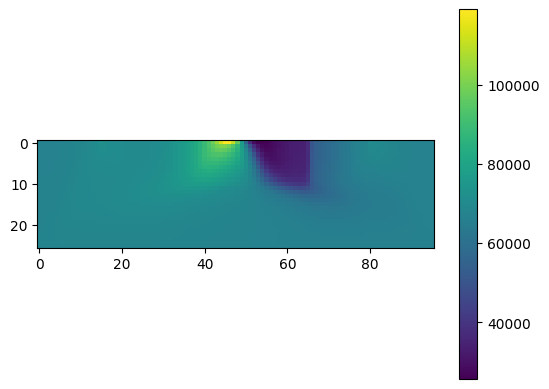

In [23]:

plt.imshow(p)
plt.colorbar()

In [24]:
from PostprocessingFunctions import load_grid
x,y = load_grid("/home/aaron99/src/CFD/CFD/CFD_FINAL3/Meshes/Airfoil/NACA64A006.coarse.53x27.grd")
#x,y = load_grid("/home/aaron99/src/CFD/CFD/CFD_FINAL3/Meshes/Airfoil/NACA64A006.medium.193x53.grd")
#x,y = load_grid("/home/aaron99/src/CFD/CFD/CFD_FINAL3/Meshes/Airfoil/NACA64A006.extra-coarse.27x14.grd")


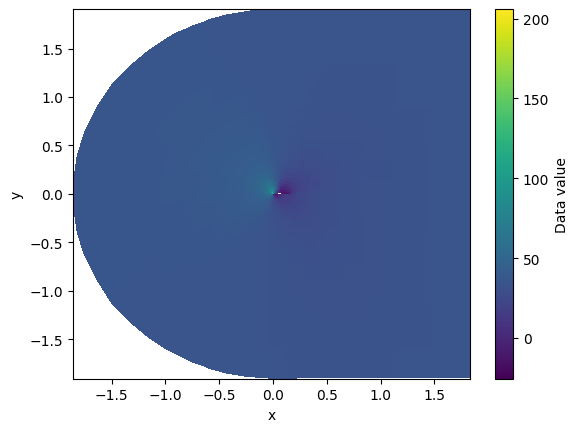

In [25]:
 

plt.pcolormesh(x[:,:], y[:,:], v[:,:], shading='auto', cmap='viridis')
plt.colorbar(label="Data value")
plt.xlabel("x")
plt.ylabel("y")
plt.show()

In [26]:

nxi_top = -(y[:,1:]-y[:,0:-1])
nyi_top = x[:,1:]-x[:,0:-1]


nxi_top = -(y[:,1:]-y[:,0:-1])
nx = (-(nxi_top)[0:-1,:])[0,:]
ny = (-(nyi_top)[0:-1,:])[0,:]


In [27]:
p_inf = 65855.8
rho_inf = 0.764876
V_inf = 291.639
chord = .1524
q_inf = .5*rho_inf*V_inf**2
q_inf

p0 = 104532

49.017955671291666

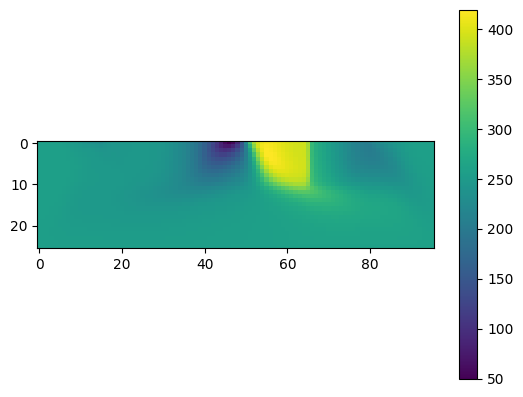

In [28]:
plt.imshow(u)

plt.colorbar()
np.min(u)

In [29]:
nx

array([ 0.00000000e+00,  0.00000000e+00,  0.00000000e+00,  0.00000000e+00,
        0.00000000e+00,  0.00000000e+00,  0.00000000e+00,  0.00000000e+00,
        0.00000000e+00,  0.00000000e+00,  0.00000000e+00,  0.00000000e+00,
        0.00000000e+00,  0.00000000e+00,  0.00000000e+00,  0.00000000e+00,
       -4.31367298e-05, -7.78491740e-05, -1.02208942e-04, -2.02959971e-04,
       -3.88114771e-04, -4.10978158e-04, -4.12398833e-04, -4.23009624e-04,
       -4.25524078e-04, -4.17356845e-04, -3.95190669e-04, -3.59691912e-04,
       -3.15049896e-04, -2.62466259e-04, -1.95954461e-04, -1.16891228e-04,
       -1.83298253e-05,  6.80000521e-05,  1.39249023e-04,  2.07598787e-04,
        2.79259635e-04,  3.57225770e-04,  4.44984995e-04,  5.66919334e-04,
        5.78807900e-04,  4.10508830e-04,  3.19456449e-04,  2.69687851e-04,
        2.48371391e-04,  2.42348353e-04,  2.33386163e-04,  2.01306844e-04,
        2.01306844e-04,  2.33386163e-04,  2.42348353e-04,  2.48372147e-04,
        2.69687327e-04,  

In [30]:
p_at_face = p[0,:]+.5*(p[1,:]-p[0,:])
(p_at_face-p_inf)/q_inf

array([ 0.04494369,  0.0445198 ,  0.04424999,  0.04418211,  0.0446643 ,
        0.04627365,  0.04970762,  0.05539307,  0.06336715,  0.07333918,
        0.08502566,  0.09850479,  0.11443607,  0.13469476,  0.16370477,
        0.20574995,  0.18079492,  0.16319509,  0.15730451,  0.16672166,
        0.14810408,  0.14192932,  0.14374834,  0.14181141,  0.13996464,
        0.13896753,  0.14060475,  0.1458675 ,  0.15401277,  0.16439454,
        0.17950184,  0.20016282,  0.23271042,  0.26863732,  0.30487286,
        0.34402097,  0.38876909,  0.44204202,  0.50805138,  0.60168761,
        0.71696378,  0.8353041 ,  0.96702175,  1.11751294,  1.26827638,
        1.35999879,  1.31986708,  1.11839966,  0.80162146,  0.37048423,
       -0.164359  , -0.67372755, -1.00682888, -1.15390908, -1.20274761,
       -1.19346789, -1.15928986, -1.12502782, -1.08981591, -1.05913045,
       -1.03279784, -1.01055592, -0.99362369, -0.98555082, -0.98205887,
       -0.873845  , -0.46370766, -0.35703037, -0.31372931, -0.27

Drag Coefficient:  -0.0009283488629582558
Lift Coefficient:  0.908650853500965
Pressure Coefficient -2.272750499630916


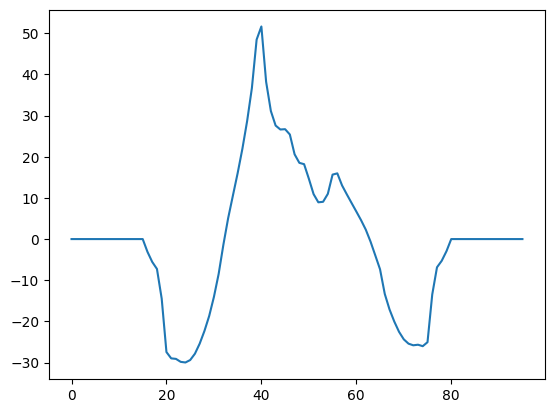

In [31]:
plt.plot(nx*p_at_face)
Den = (.5*rho_inf*V_inf**2)*chord
print("Drag Coefficient: ",np.sum(nx*p_at_face)/Den)
print("Lift Coefficient: ",np.sum((ny*p_at_face)[8*2:-8*2]/Den))
print("Pressure Coefficient",(np.sum((p_at_face-p_inf)[8*2:-8*2]*chord/Den)))

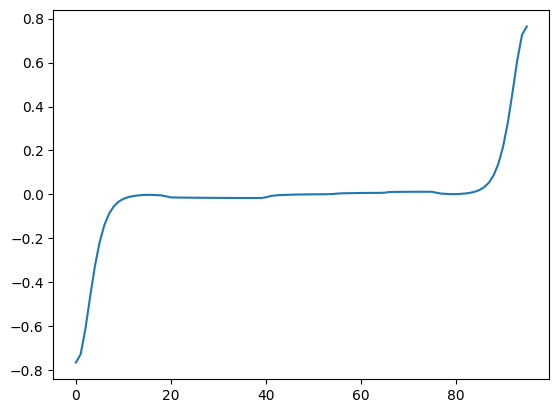

In [32]:

plt.plot(-ny*p_at_face*chord/Den)

In [33]:
gamma = 1.4


V2 = u**2 + v**2
a2 = gamma * p / rho
M2 = V2 / a2
Mach = np.sqrt(M2)

In [34]:

write_vtk("/home/aaron99/src/CFD/CFD/CFD_FINAL3/Meshes/Airfoil/NACA64A006.medium.193x53.grd",Mach,u,v,p,output_name="../VTK/Airfoil_Medium_Mach_AOA.vtk")

ValueError: Input point array shapes must match exactly

In [ ]:
import numpy as np, math
# D: [Supercoarse, Coarse, Medium]
D = np.array([0.025910345032662364, 0.018382755717889214, 0.01106595689793473], float)
r = 2.0
f3, f2, f1 = D

# apparent order
p = math.log((f3 - f2) / (f2 - f1), r)

# 3-grid Richardson (may be unreliable if not asymptotic)
D_ext_3 = f1 + (f1 - f2) / (r**p - 1)

# 2-grid extrapolations assuming formal order
D_ext_p1 = f1 + (f1 - f2) / (r**1 - 1)   # p=1
D_ext_p2 = f1 + (f1 - f2) / (r**2 - 1)   # p=2

print("p =", p)
print("D_ext_3 =", D_ext_3)
print("D_ext_p1 =", D_ext_p1)
print("D_ext_p2 =", D_ext_p2)


In [ ]:
plt.contour(x,y,Mach)